In [2]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Data Understanding

Dataset contains customer demographic and spending information.

Checked dataset shape and structure.

Verified data types.

Checked for missing values.

Data is clean and ready for analysis.

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual_Income,int64
Spending_Score,int64


In [10]:
df.describe()

,CustomerID,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
df['Gender'].value_counts()

,count
Gender,
Female,112
Male,88


In [12]:
import matplotlib.pyplot as plt

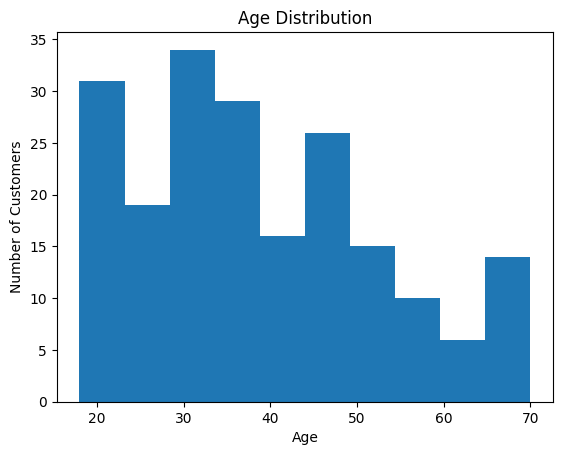

In [13]:
plt.hist(df['Age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

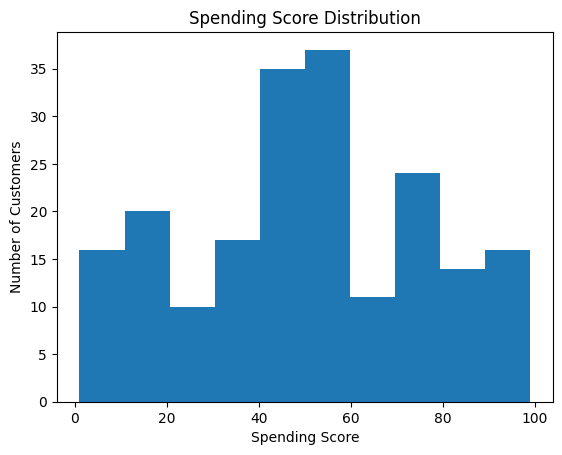

In [14]:
plt.hist(df['Spending_Score'], bins=10)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')
plt.show()

Data Cleaning & Initial Analysis

Checked and removed duplicate records.

Renamed columns for easier analysis.

Verified data types.

Generated summary statistics.

Analyzed gender distribution.

Visualized age and spending patterns.

Data is now clean and ready for customer segmentation.

In [15]:
def spending_category(score):
    if score <= 33:
        return 'Low'
    elif score <= 66:
        return 'Medium'
    else:
        return 'High'

df['Spending_Level'] = df['Spending_Score'].apply(spending_category)
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Spending_Level
0,1,Male,19,15,39,Medium
1,2,Male,21,15,81,High
2,3,Female,20,16,6,Low
3,4,Female,23,16,77,High
4,5,Female,31,17,40,Medium


In [16]:
df['Spending_Level'].value_counts()

,count
Spending_Level,
Medium,94
High,57
Low,49


In [17]:
import matplotlib.pyplot as plt


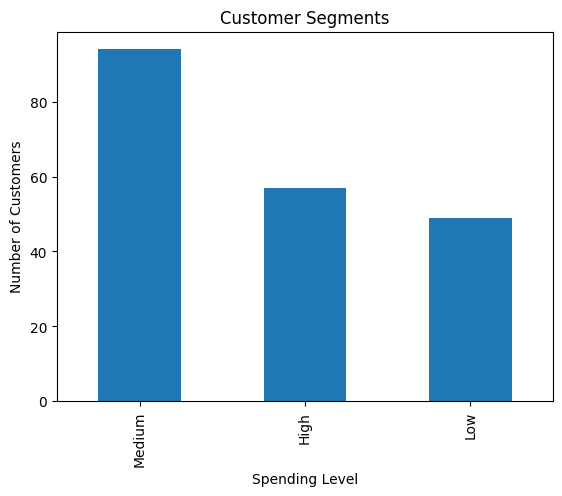

In [18]:
df['Spending_Level'].value_counts().plot(kind='bar')
plt.title('Customer Segments')
plt.xlabel('Spending Level')
plt.ylabel('Number of Customers')
plt.show()

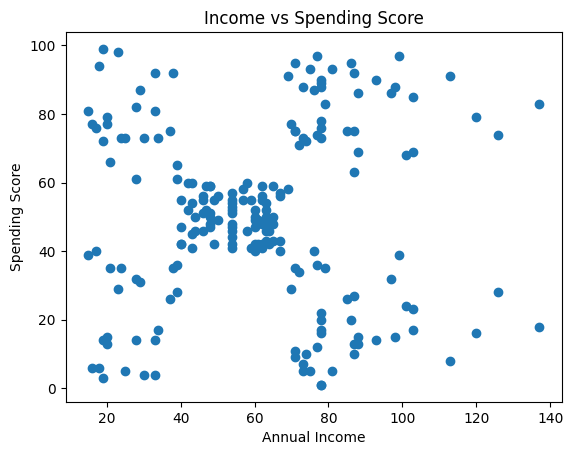

In [19]:
plt.scatter(df['Annual_Income'], df['Spending_Score'])
plt.title('Income vs Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

In [20]:
df.groupby('Spending_Level')['Annual_Income'].mean()

,Annual_Income
Spending_Level,
High,66.070175
Low,67.000000
Medium,53.861702


Customer Segmentation

Customers were segmented into Low, Medium, and High spenders based on Spending Score.

Created a new feature: Spending_Level.

Analyzed distribution of customer segments.

Visualized income vs spending behavior.

Identified differences in income across customer groups.

This segmentation helps businesses target high-value customers effectively.

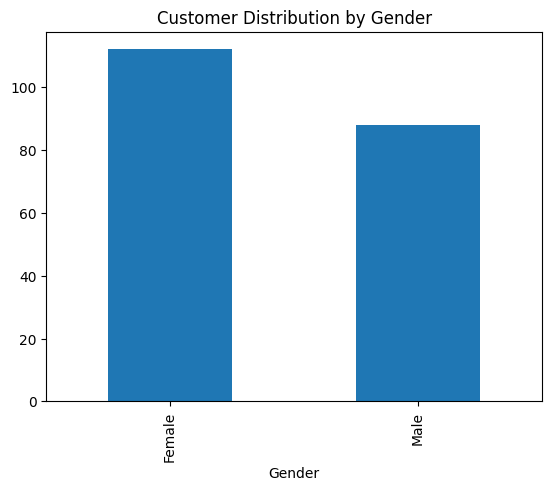

In [25]:
gender_count = df['Gender'].value_counts()

gender_count.plot(kind='bar')
plt.title("Customer Distribution by Gender")
plt.show()

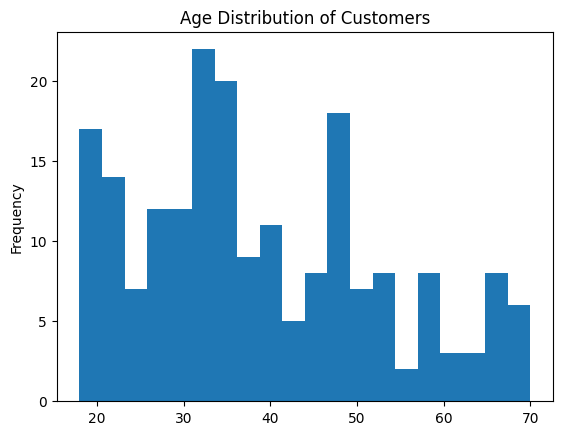

In [26]:
df['Age'].plot(kind='hist', bins=20)
plt.title("Age Distribution of Customers")
plt.show()

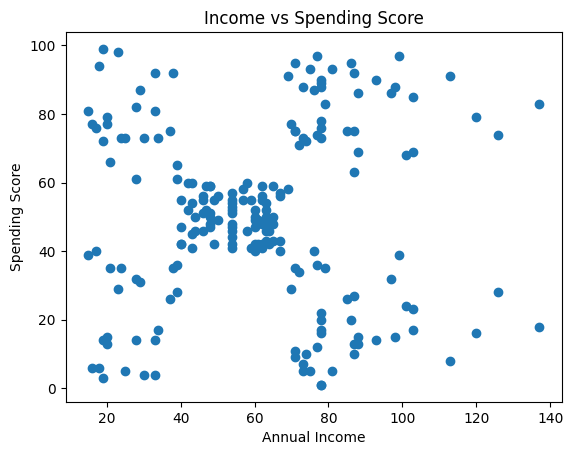

In [27]:
plt.scatter(df['Annual_Income'], df['Spending_Score'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

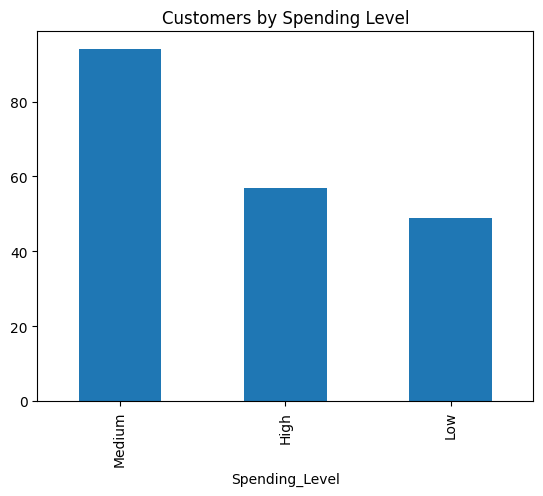

In [28]:
spending_level = df['Spending_Level'].value_counts()

spending_level.plot(kind='bar')
plt.title("Customers by Spending Level")
plt.show()

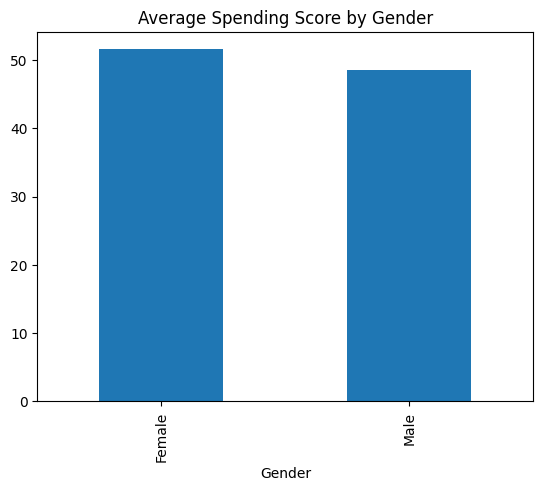

In [29]:
avg_spending_gender = df.groupby('Gender')['Spending_Score'].mean()

avg_spending_gender.plot(kind='bar')
plt.title("Average Spending Score by Gender")
plt.show()

Female customers have slightly higher spending scores.

Most customers are aged between 25–40.

High-income customers do not always spend more.

Majority customers fall in the medium spending category.

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [31]:
X = df[['Annual_Income', 'Spending_Score']]

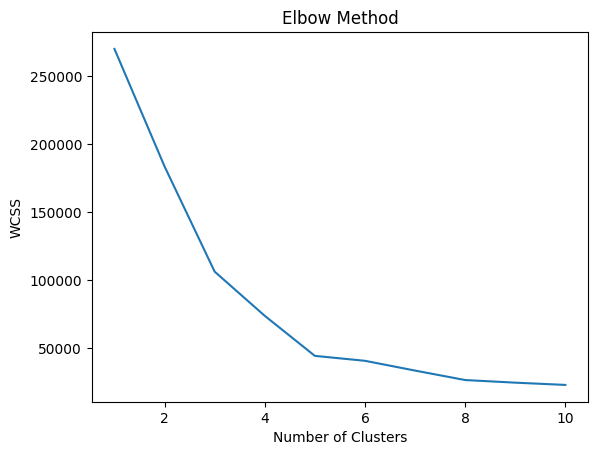

In [32]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [34]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

In [35]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Spending_Level,Cluster
0,1,Male,19,15,39,Medium,4
1,2,Male,21,15,81,High,2
2,3,Female,20,16,6,Low,4
3,4,Female,23,16,77,High,2
4,5,Female,31,17,40,Medium,4


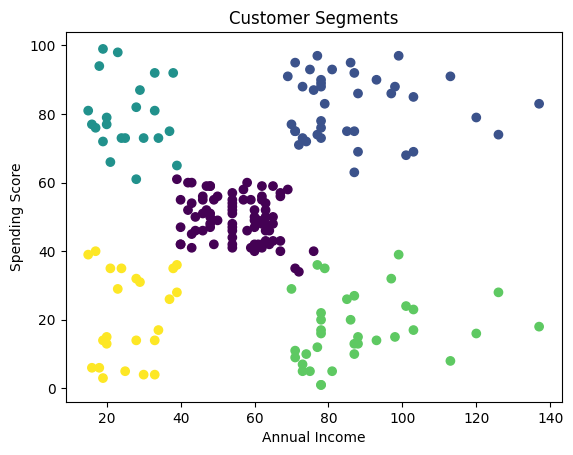

In [36]:
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

In [37]:
df.groupby('Cluster')[['Annual_Income', 'Spending_Score']].mean()

,Annual_Income,Spending_Score
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


Cluster 0: High income, high spending → Premium customers

Cluster 1: High income, low spending → Target for marketing

Cluster 2: Low income, high spending → Impulsive buyers

Cluster 3: Low income, low spending → Low-value customers

Cluster 4: Medium income, medium spending → Regular customers

In [38]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Spending_Level,Cluster
0,1,Male,19,15,39,Medium,4
1,2,Male,21,15,81,High,2
2,3,Female,20,16,6,Low,4
3,4,Female,23,16,77,High,2
4,5,Female,31,17,40,Medium,4


In [39]:
df.to_csv("Customer_Segmentation_Final.csv", index=False)

In [40]:
from google.colab import files
files.download("Customer_Segmentation_Final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [42]:
cluster_summary = df.groupby('Cluster')[['Annual_Income', 'Spending_Score']].mean()
cluster_summary

,Annual_Income,Spending_Score
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [43]:
cluster_summary.to_csv("Cluster_Summary.csv")